Make imports and load the data in the correct folder:

In [3]:
import pandas as pd
import numpy as np
import os
import chromatin_tracing_python.image_processing_functions as ip
import chromatin_tracing_python.trace_analysis_functions as tr

wdir = r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\04_ANALYSIS"+os.sep
prefix = '20200603_Exp328_KSB_Elyra_tracing_myc_D1-10_'
traces = pd.read_csv(wdir+prefix+'traces.csv')
rois = pd.read_csv(wdir+prefix+'rois.csv')
imgs=np.moveaxis(ip.read_tif_image(wdir+prefix+'imgs.tif'),1,2)

In [8]:
image_dir = r"M:\ChromatinTeam\Images_processing\20200603_Exp328_KSB_Elyra_tracing_myc_D1-10\02_DECON"
all_images, groups = ip.svih5_to_dask(image_dir, ['.h5', 'DE_2'])
import napari
with napari.gui_qt():
    viewer = napari.view_image(all_images[:,:,0], contrast_limits=(0,50000), blending='additive', colormap='magenta')
    viewer.add_image(all_images[:,:,1], contrast_limits=(0,2000), blending='additive', colormap='green')
    viewer.add_image(all_images[:,:,2], contrast_limits=(0,2000), blending='additive', colormap='blue')

Loaded images, final shape  (15, 14, 3, 1, 40, 1280, 1280)


Once we have the traces loaded or calculated, we can look at the trace dataframe. It has a multilevel index with a unique trace ID as main index, and image name, nuclear ownership and frame nr as secondary index for each point. Each fitted point is documented with the full output of the gaussian fit, as well as a quality control metric defined from the config file. Units in nm.

In [4]:
traces.query('trace_ID == 50')

,trace_ID,frame,position,roi_ID,BG,A,z_px,y_px,x_px,sigma_z,sigma_xy,z,y,x
700,50,0,W0005,7.0,17.299447,417421.368444,0.645758,10.561361,42.911800,721.608245,471.006919,129.151671,1024.451992,4162.444570
701,50,1,W0005,7.0,88.026967,3018.596309,4.563118,5.420475,6.269193,207.399367,71.102271,912.623506,525.786116,608.111722
702,50,2,W0005,7.0,90.626252,6165.839018,4.858938,5.141472,6.104657,187.497588,64.999270,971.787534,498.722742,592.151770
703,50,3,W0005,7.0,74.747734,1279.603296,5.423175,4.964446,5.055195,244.471784,80.890342,1084.635014,481.551280,490.353873
704,50,4,W0005,7.0,122.396870,1390.201794,4.958237,5.480321,4.986952,303.508859,101.816871,991.647488,531.591166,483.734386
705,50,5,W0005,7.0,100.266788,495.339612,5.617034,4.883951,4.570634,256.960180,91.702904,1123.406886,473.743201,443.351458
706,50,6,W0005,7.0,92.937796,838.979266,5.214927,4.777589,4.636771,244.530789,83.894531,1042.985457,463.426137,449.766767
707,50,7,W0005,7.0,60.201076,119.522327,3.225996,5.980428,6.242834,394.466214,132.270885,645.199232,580.101481,605.554886
708,50,8,W0005,7.0,139.948932,1818.056405,0.337113,1.949542,11.270764,271.202033,97.092627,67.422699,189.105616,1093.264107
709,50,9,W0005,7.0,85.747503,2322.494032,3.972089,4.358137,5.877419,247.188931,87.400720,794.417884,422.739322,570.109680


We can easily visualize one or more traces by their trace_IDs now, either one or several (by a list of trace_IDs). To do this we load the tracing functions module that contains several helper functions for trace analysis.

In [6]:
tr.plot_traces(traces,[11])

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36']


Let us get some more statistics on our traces:

In [7]:
import plotly.express as px
px.histogram(traces.groupby(level='trace_ID').sum(), x='QC', width=500)

In [12]:
px.bar(traces.groupby('frame').median(), y='A', width=500)

Visualize fits on top of actual image data using napari.

In [13]:
import napari
points=tr.points_for_overlay(traces.query('QC == 1'))
with napari.gui_qt():
    viewer = napari.view_image(np.moveaxis(np.max(imgs,axis=2),0,1), contrast_limits=(100,10000))
    viewer.add_points(points[:,(0,1,3,4)], size=[0,0,1,1], face_color='red', symbol='cross', n_dimensional=True)

Depending on the quality of the dataset, some traces might be too short for a useful anaylsis. These can be filtered out from the traces and pair-wise distance matrix before analysing further. Once filtered, we can get a sense of the data from the average pwd matrix (missing distances are nan, so we have to use nanmean).

In [14]:
traces_long = tr.tracing_length_qc(traces, min_length=9)
pwds_long = tr.pwd_calc(traces_long)

In [21]:
print('Number of traces in analysis: ', pwds_long.shape[0])
pwds_mean=np.clip(np.round(-np.nanmedian(pwds_long, axis=0),0).astype(int),-300,0)
px.imshow(pwds_mean)

Number of traces in analysis:  123


In [ ]:
import plotly.figure_factory as ff
fig = ff.create_annotated_heatmap(pwds_mean,colorscale='hot',annotation_text='')
fig.update_layout(
    width = 600,
    height = 600,
    yaxis_autorange="reversed"
)
fig.show()

Further, we can do a paired analysis on traces to figure out similarities between sets of traces. The output of this analysis contains the original indexes and point coordinates of the two compared indexes, the second trace aligned to the first by least squares fitting, and three metrics of similarity between the two traces. These are the mse of the alignment, and the mse of the two pair-wise distance matrices, as well as the Pearson's correlation coefficient between the PWDs. We sort the matrix for to find pairs with a high PCC.

In [22]:
pairs = tr.trace_analysis(traces_long, pwds_long)

In [10]:
pairs.sort_values(by=['aligned_mse'], ascending=True).head()

,idx1,idx2,aligned_mse,aligned_pcc,pwd_mse,pwd_pcc
3159,63,88,17.835544,0.992837,14.424601,0.244497
3902,81,135,48.192279,0.988021,64.062596,0.672794
2794,56,156,63.416131,0.951536,72.690759,0.706810
2731,56,60,68.299232,0.931715,62.417033,0.554361
2173,40,135,68.747879,0.973544,67.273978,0.770615


We can visualize the aligned traces by their index in the pair matrix.

In [85]:
tr.plot_aligned_traces(traces,[30,31])

We can immediately use the paired similarity values to group the traces. We can use any of the three similarity metrics defined in the pairs analysis. This constructs a dendrogram showing simple hierichal grouping of the dataset. The labels in the dendrogram are the original trace_id of each trace.

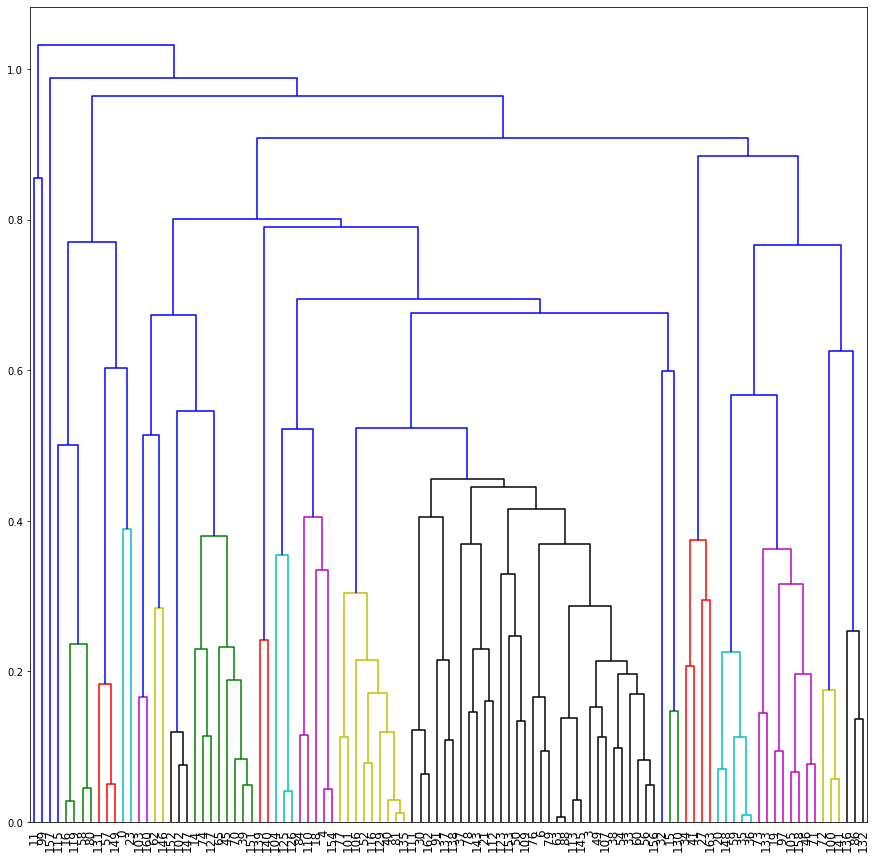

In [68]:
cluster_df = tr.trace_clustering(pairs, metric='aligned_pcc', method='average', color_threshold=0.5)

In [86]:
cluster_id = 10
cluster_members = cluster_df[cluster_df['cluster']==cluster_id]['trace_ID'].values
print(cluster_members)

[ 14  39  45  65  70  74 127 151]


In [87]:
clust_aligned, clust_mean = tr.general_procrustes_analysis(traces, cluster_members)
tr.plot_gpa_output(clust_aligned, clust_mean)

Initial distance is 1211.7936180362608
GPA converged after 4 cycles with distance 320.0420333564067
[ 1  2  3  4  5  6  7  8  9 10]


We can visualize these individually as before. To visualize pairs in the identified grouping, we can look up the index in the pairs analysis and plot these using the paired plotting function as well. Note that for lookups in the pairs dataframe the lower index is always idx1, the higher idx2.

In [88]:
aligned_all_gpa=tr.run_gpa_all_clusters(traces_long, cluster_df, min_cluster=2)
tr.plot_multi_points(aligned_all_gpa)

[[16, 58, 80, 119], [57, 131, 149], [0, 23], [103, 160], [62, 146], [102, 147, 152], [14, 39, 45, 65, 70, 74, 127, 151], [139, 140], [104, 125, 126], [4, 18, 84, 110, 154], [40, 52, 77, 81, 101, 106, 116, 129, 135], [3, 6, 21, 30, 33, 37, 38, 49, 50, 54, 56, 60, 63, 76, 78, 79, 88, 91, 107, 109, 111, 112, 113, 123, 137, 138, 143, 145, 153, 156, 162], [15, 130], [27, 34, 41, 163], [20, 35, 36, 59, 148], [19, 46, 71, 73, 97, 105, 133, 158], [72, 100, 141], [86, 132, 136]]
Initial distance is 427.2094507514895
GPA converged after 5 cycles with distance 139.8282242399578
Initial distance is 245.15160124226537
GPA converged after 4 cycles with distance 88.78175258366217
Initial distance is 154.74518095626968
GPA converged after 1 cycles with distance 54.96375650974291
Initial distance is 108.56574395471294
GPA converged after 1 cycles with distance 54.51928788920406
Initial distance is 185.7871066520343
GPA converged after 1 cycles with distance 52.97298229958823
Initial distance is 199.977

In [89]:
tr.radius_of_gyration(clust_mean)

151.6029598665483

In [90]:
tr.elongation(clust_mean)

[ 555.41582848 1930.96388813 5174.77276349]


0.6268504963621102